In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install shap

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/Thesis v3/2 Model/vgg16.keras')

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_52 (Conv1D)              │ (None, 51, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 51, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_64 (Activation)      │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_53 (Conv1D)              │ (None, 51, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 51, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_65 (Activation)      │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_54 (Conv1D)              │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_66 (Activation)      │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_55 (Conv1D)              │ (None, 25, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_56 (Conv1D)              │ (None, 12, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_68 (Activation)      │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_57 (Conv1D)              │ (None, 12, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 12, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_69 (Activation)      │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_58 (Conv1D)              │ (None, 12, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 12, 256)        │         1,02

 Total params: 71,493,576 (272.73 MB)

 Trainable params: 23,822,914 (90.88 MB)

 Non-trainable params: 24,832 (97.00 KB)

 Optimizer params: 47,645,830 (181.75 MB)

In [ ]:
import pandas as pd

df_train = pd.read_csv("/content/drive/MyDrive/Thesis v3/1 Extracted Features/df_train.csv")
#df_train

In [ ]:
df_test = pd.read_csv("/content/drive/MyDrive/Thesis v3/1 Extracted Features/df_test.csv")
#df_test

In [ ]:
import tensorflow as tf

In [ ]:
X = df_train.drop('audio_type', axis=1).values
y = df_train['audio_type'].values

# Encode categorical labels to numerical
from sklearn.preprocessing import LabelEncoder, StandardScaler
label_encoder = LabelEncoder()
y_numerical = label_encoder.fit_transform(y)

# One-hot encode numerical labels
y_one_hot = tf.keras.utils.to_categorical(y_numerical, num_classes=2)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check for NaN values in features
if np.isnan(X_scaled).any():
    print("Warning: NaN values found in scaled features (X_scaled). This can cause 'nan' loss during training.")
else:
    print("No NaN values found in scaled features (X_scaled).")

No NaN values found in scaled features (X_scaled).


In [ ]:
from sklearn.model_selection import KFold, train_test_split

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.1, random_state=42)

X_train_full = X_train_full.reshape(X_train_full.shape[0], 51, 1)
X_test = X_test.reshape(X_test.shape[0], 51, 1)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

fold_no = 1
scores = []

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix

In [ ]:
# 3. Final Evaluation on Test Data
# Train final model on full training set and evaluate on the 30% held-out test set
print("\nTraining Final Model on full Training Set...")
final_model = model
final_model.fit(X_train_full, y_train_full, batch_size=32, epochs=30, verbose=0)

loss, accuracy = final_model.evaluate(X_test, y_test, verbose=0)

y_pred = np.argmax(final_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\n--- Final MIDs Results (Test Set) ---")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")


Training Final Model on full Training Set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step

--- Final MIDs Results (Test Set) ---
Accuracy: 77.78%
Sensitivity: 72.73%
Specificity: 82.61%


In [ ]:
X_test_data = df_test.drop('audio_type', axis=1).values
y_test_data = df_test['audio_type'].values

# Encode categorical labels to numerical using the fitted label_encoder
y_numerical_test = label_encoder.transform(y_test_data)

# One-hot encode numerical labels
y_one_hot_test = tf.keras.utils.to_categorical(y_numerical_test, num_classes=2)

# Normalize features using the fitted scaler
X_scaled_test = scaler.transform(X_test_data)

# Reshape input to (Samples, 51, 1) for 1D CNN
X_scaled_test = X_scaled_test.reshape(X_scaled_test.shape[0], 51, 1)

# Evaluate the final model on the test data
loss_test, accuracy_test = final_model.evaluate(X_scaled_test, y_one_hot_test, verbose=0)

# Make predictions on the test data
y_pred_probs_test = final_model.predict(X_scaled_test)
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_one_hot_test, axis=1)

# Compute the confusion matrix
conf_matrix_test = confusion_matrix(y_true_test, y_pred_test)
tn_test, fp_test, fn_test, tp_test = conf_matrix_test.ravel()

# Calculate Sensitivity and Specificity
sensitivity_test = tp_test / (tp_test + fn_test)
specificity_test = tn_test / (tn_test + fp_test)

print(f"\n--- Evaluation on df_test --- ")
print(f"Test Accuracy: {accuracy_test*100:.2f}%")
print(f"Test Sensitivity: {sensitivity_test*100:.2f}%")
print(f"Test Specificity: {specificity_test*100:.2f}%")
print(f"Confusion Matrix:\n{conf_matrix_test}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 328ms/step

--- Evaluation on df_test --- 
Test Accuracy: 81.25%
Test Sensitivity: 80.36%
Test Specificity: 82.14%
Confusion Matrix:
[[46 10]
 [11 45]]


In [ ]:
import shap

In [ ]:
def f(x):
    # Reshape the input x to (samples, 51, 1) as required by the model
    x_reshaped = x.reshape(x.shape[0], 51, 1)
    # Get the model's predictions (probabilities for each class)
    preds = final_model.predict(x_reshaped, verbose=0)
    # For binary classification, SHAP often works best with the probability of the positive class
    # Now explaining Class 0 (myocardial)
    return preds[:, 0]

In [ ]:
background_data_2d = X_scaled[np.random.choice(X_scaled.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(f, background_data_2d)

In [ ]:
# Compute SHAP values for the NEXT 40 test samples (indices 20-60)
# This avoids re-calculating the first 20 and saves time
X_scaled_test_reshaped = X_scaled_test.reshape(X_scaled_test.shape[0], X_scaled_test.shape[1])

start_idx_shap = 20
end_idx_shap = 60

print(f"Calculating SHAP values for samples {start_idx_shap} to {end_idx_shap}...")
shap_values_batch = explainer.shap_values(X_scaled_test_reshaped[start_idx_shap:end_idx_shap])

Calculating SHAP values for samples 20 to 60...


  0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
# Select only the first instance from the test data for explanation
one_instance_to_explain = X_scaled_test_reshaped[0:1]
shap_attributions = shap_values_batch[0]

In [ ]:
def calculate_faithfulness(model, X_sample, attribution_values, top_k=5):
    """
    Measures how much the prediction drops when top_k features are masked.

    Returns:
        drop_score: (Original Prob - Perturbed Prob). Higher is better.
    """
    # Get original prediction
    # Reshape for keras (1, 51, 1)
    X_sample_reshaped = X_sample.reshape(1, 51, 1)
    original_prob = model.predict(X_sample_reshaped, verbose=0)[0][0]

    # Identify indices of the top_k most important features (absolute value)
    importance_scores = np.abs(attribution_values)
    top_indices = np.argsort(importance_scores)[-top_k:]

    # Create perturbed sample (Masking top features to 0)
    X_perturbed = X_sample.copy()
    X_perturbed[0, top_indices] = 0.0  # Or set to X_train.mean() if 0 isn't neutral

    # Reshape for keras (1, 51, 1)
    X_perturbed_reshaped = X_perturbed.reshape(1, 51, 1)
    perturbed_prob = model.predict(X_perturbed_reshaped, verbose=0)[0][0]

    # Calculate drop
    drop_score = original_prob - perturbed_prob
    return drop_score

In [ ]:
num_samples = 40
start_index = 20
scores_shap = []

print(f"Calculating faithfulness for {num_samples} samples (indices {start_index} to {start_index + num_samples})...")
for i in range(num_samples):
    # Global index for the instance in the test set
    global_idx = start_index + i
    instance = X_scaled_test_reshaped[global_idx : global_idx+1]

    # Attributions from the calculated batch (local index i corresponds to global_idx)
    attributions = shap_values_batch[i]

    # Calculate score
    score = calculate_faithfulness(model, instance, attributions, top_k=5)
    scores_shap.append(score)

# Calculate average
score_shap = np.mean(scores_shap)
print(f"Average Faithfulness Score (SHAP) over samples {start_index}-{start_index+num_samples}: {score_shap:.5f}")

Calculating faithfulness for 40 samples (indices 20 to 60)...
Average Faithfulness Score (SHAP) over samples 20-60: 0.23165


In [ ]:
print(f"Average Faithfulness Score (SHAP) over {num_samples} samples: {score_shap}")

Average Faithfulness Score (SHAP) over 40 samples: 0.2316545993089676


In [ ]:
feature_names = df_train.drop('audio_type', axis=1).columns.tolist()

/tmp/ipython-input-2253430040.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_scaled_test_reshaped, feature_names=feature_names, plot_type='bar', max_display=10, show=False)


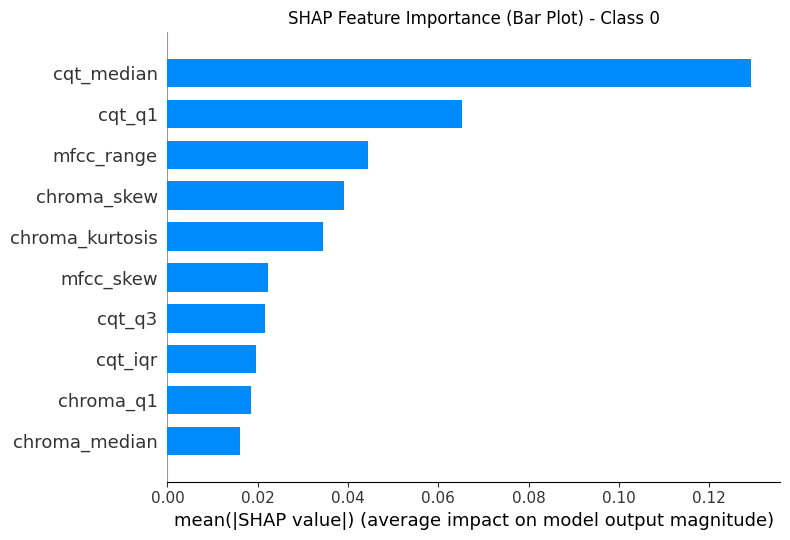

SHAP summary plot (bar) generated.


In [ ]:
shap.summary_plot(shap_values, X_scaled_test_reshaped, feature_names=feature_names, plot_type='bar', max_display=10, show=False)
plt.title('SHAP Feature Importance (Bar Plot) - Class 0')
plt.tight_layout()
plt.show()
print("SHAP summary plot (bar) generated.")

In [ ]:
# Calculate mean absolute SHAP values (global importance)
# If shap_values is a list (multi-output), take the first one; otherwise use it directly
if isinstance(shap_values, list):
    global_shap_values = np.abs(shap_values[0]).mean(axis=0)
else:
    global_shap_values = np.abs(shap_values).mean(axis=0)

# Create a DataFrame for easy sorting
feature_importance = pd.DataFrame(list(zip(feature_names, global_shap_values)), columns=['feature', 'importance'])
feature_importance.sort_values(by='importance', ascending=False, inplace=True)

print("--- Top 3 Features from Bar Plot (Mean |SHAP value|) ---")
print(feature_importance.head(3))

--- Top 3 Features from Bar Plot (Mean |SHAP value|) ---
       feature  importance
20  cqt_median    0.129198
23      cqt_q1    0.065272
17  mfcc_range    0.044489


In [ ]:
feature_groups = {
    'DWT': ['dwt_mean', 'dwt_max', 'dwt_min', 'dwt_median', 'dwt_q1', 'dwt_q3', 'dwt_iqr'],
    'MFCC': ['mfcc_mean', 'mfcc_std', 'mfcc_max', 'mfcc_median', 'mfcc_var', 'mfcc_skew', 'mfcc_kurtosis', 'mfcc_q1', 'mfcc_q3', 'mfcc_iqr', 'mfcc_range'],
    'CQT': ['cqt_mean', 'cqt_min', 'cqt_median', 'cqt_var', 'cqt_kurtosis', 'cqt_q1', 'cqt_q3', 'cqt_iqr', 'cqt_range'],
    'Chroma': ['chroma_mean', 'chroma_std', 'chroma_max', 'chroma_min', 'chroma_median', 'chroma_var', 'chroma_skew', 'chroma_kurtosis', 'chroma_q1', 'chroma_q3', 'chroma_iqr', 'chroma_range'],
    'RMS': ['rms_mean', 'rms_std', 'rms_max', 'rms_min', 'rms_median', 'rms_var', 'rms_skew', 'rms_kurtosis', 'rms_q1', 'rms_q3', 'rms_iqr', 'rms_range'],
    'Shannon Entropy': ['shannon_entropy']
}

grouped_importances = {group_name: 0.0 for group_name in feature_groups.keys()}

# global_shap_values is already calculated as mean(|SHAP|) in the previous cell
# We iterate through features and sum their global importance into groups

for i, feature_name in enumerate(feature_names):
    for group_name, group_features in feature_groups.items():
        if feature_name in group_features:
            grouped_importances[group_name] += global_shap_values[i]
            break # Move to the next feature once it's assigned to a group

print("--- Aggregated Global SHAP Feature Importance by Group ---")
for group_name, total_importance in sorted(grouped_importances.items(), key=lambda item: item[1], reverse=True):
    print(f"{group_name}: {total_importance:.5f}")

--- Aggregated Global SHAP Feature Importance by Group ---
CQT: 0.27646
Chroma: 0.15426
MFCC: 0.14097
DWT: 0.02492
RMS: 0.02367
Shannon Entropy: 0.00000


In [ ]:
ig_explainer = shap.GradientExplainer(final_model, X_train_full)

In [ ]:
ig_values = ig_explainer.shap_values(X_scaled_test)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(112, 51, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(50, 51, 1))']
  warnings.warn(msg)


In [ ]:
num_samples = 40
scores_ig = []

print(f"Calculating faithfulness for {num_samples} samples...")
for i in range(num_samples):
    # Get the instance (keeping 2D shape (1, 51)) and its attributions
    instance = X_scaled_test_reshaped[i:i+1]
    attributions = ig_values[i]

    # Calculate score
    score = calculate_faithfulness(model, instance, attributions, top_k=5)
    print(score)
    scores_ig.append(score)

# Calculate average
score_ig = np.mean(scores_ig)
print(f"Average Faithfulness Score (SHAP) over {num_samples} samples: {score_ig:.5f}")

Calculating faithfulness for 40 samples...
0.010100272
-2.026558e-06
-2.7418137e-06
-0.0025592446
1.5497208e-06
-0.0001963377
-6.240606e-05
-6.174896e-06
0.23606557
0.0015380383
-4.172325e-06
-9.655952e-06
-0.071023285
9.536743e-07
-2.503395e-06
-1.7881393e-06
-8.583069e-06
0.0010679364
-0.00022625923
-4.6491623e-06
2.2649765e-06
1.1920929e-07
-1.6510487e-05
-5.1259995e-06
-3.2246113e-05
-3.2186508e-06
-0.033610493
-4.172325e-06
-2.3841858e-06
-8.702278e-06
-6.055832e-05
-0.00050230324
0.00017380714
-9.62615e-05
-1.2874603e-05
-0.0029472113
-0.0077469945
-2.2053719e-05
-5.8293343e-05
-6.198883e-06
Average Faithfulness Score (SHAP) over 40 samples: 0.00324


Original ig_values shape: (112, 51, 1, 2)
X_scaled_test shape: (112, 51, 1)
Detected stacked array format (N, H, W, C).
Plotting shapes - SHAP: (112, 51), X: (112, 51)


/tmp/ipython-input-3200930763.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, X_to_plot, feature_names=feature_names, plot_type='bar', max_display=10, show=False)


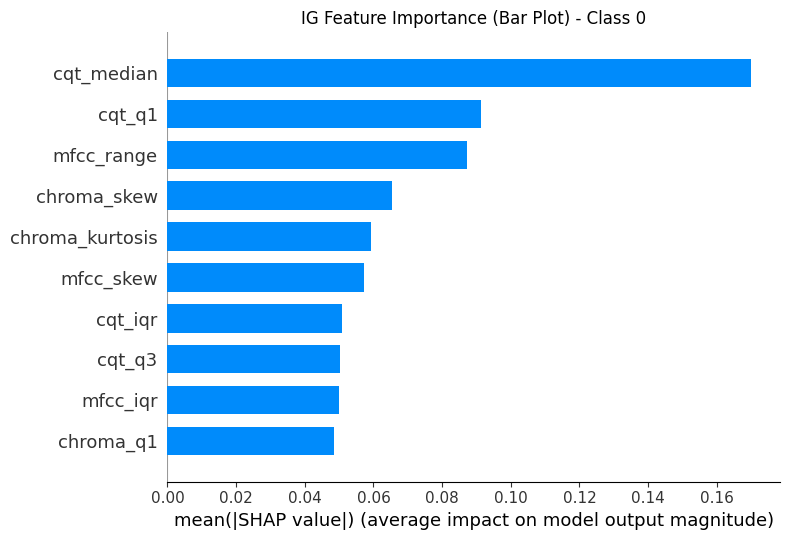

IG summary plot (bar) generated.


In [ ]:
print(f"Original ig_values shape: {np.array(ig_values).shape}")
print(f"X_scaled_test shape: {X_scaled_test.shape}")

# 1. Handle Input Structure
if isinstance(ig_values, list):
    # Standard SHAP list output: [Class0_Array, Class1_Array]
    shap_values_to_plot = ig_values[0]
    print("Detected list format.")
elif len(ig_values.shape) == 4 and ig_values.shape[-1] == 2:
    # Stacked array output: (Samples, Features, Channels, Classes)
    # Take Class 0
    shap_values_to_plot = ig_values[..., 0]
    print("Detected stacked array format (N, H, W, C).")
else:
    # Fallback / Single output
    shap_values_to_plot = ig_values
    print("Detected standard array format.")

# 2. Reshape to 2D (Samples, Features)
# Flatten (Samples, 51, 1) -> (Samples, 51)
shap_values_to_plot = shap_values_to_plot.reshape(shap_values_to_plot.shape[0], -1)
X_to_plot = X_scaled_test.reshape(X_scaled_test.shape[0], -1)

print(f"Plotting shapes - SHAP: {shap_values_to_plot.shape}, X: {X_to_plot.shape}")

# 3. Generate Plot
shap.summary_plot(shap_values_to_plot, X_to_plot, feature_names=feature_names, plot_type='bar', max_display=10, show=False)
plt.title('IG Feature Importance (Bar Plot) - Class 0')
plt.tight_layout()
plt.show()
print("IG summary plot (bar) generated.")

In [ ]:
# Calculate mean absolute IG values (global importance)
# Handle 4D shape (Samples, Features, Channels, Classes) or List

if isinstance(ig_values, list):
    # List case: [Class0, Class1]
    # ig_values[0] shape: (Samples, 51, 1)
    # Mean over samples -> (51, 1) -> Flatten to (51,)
    global_ig_values = np.abs(ig_values[0]).mean(axis=0).flatten()
elif len(ig_values.shape) == 4 and ig_values.shape[-1] == 2:
    # Stacked case: (Samples, 51, 1, 2)
    # Select Class 0 -> (Samples, 51, 1)
    # Mean over samples -> (51, 1) -> Flatten to (51,)
    global_ig_values = np.abs(ig_values[..., 0]).mean(axis=0).flatten()
else:
    # Standard case: (Samples, Features)
    global_ig_values = np.abs(ig_values).mean(axis=0).flatten()

# Create a DataFrame for easy sorting
feature_importance = pd.DataFrame(list(zip(feature_names, global_ig_values)), columns=['feature', 'importance'])
feature_importance.sort_values(by='importance', ascending=False, inplace=True)

print("--- Top 3 Features from IG Bar Plot (Mean |IG value|) ---")
print(feature_importance.head(3))

--- Top 3 Features from IG Bar Plot (Mean |IG value|) ---
       feature  importance
20  cqt_median    0.169933
23      cqt_q1    0.091262
17  mfcc_range    0.087160


In [ ]:
feature_groups_ig = {
    'DWT': ['dwt_mean', 'dwt_max', 'dwt_min', 'dwt_median', 'dwt_q1', 'dwt_q3', 'dwt_iqr'],
    'MFCC': ['mfcc_mean', 'mfcc_std', 'mfcc_max', 'mfcc_median', 'mfcc_var', 'mfcc_skew', 'mfcc_kurtosis', 'mfcc_q1', 'mfcc_q3', 'mfcc_iqr', 'mfcc_range'],
    'CQT': ['cqt_mean', 'cqt_min', 'cqt_median', 'cqt_var', 'cqt_kurtosis', 'cqt_q1', 'cqt_q3', 'cqt_iqr', 'cqt_range'],
    'Chroma': ['chroma_mean', 'chroma_std', 'chroma_max', 'chroma_min', 'chroma_median', 'chroma_var', 'chroma_skew', 'chroma_kurtosis', 'chroma_q1', 'chroma_q3', 'chroma_iqr', 'chroma_range'],
    'RMS': ['rms_mean', 'rms_std', 'rms_max', 'rms_min', 'rms_median', 'rms_var', 'rms_skew', 'rms_kurtosis', 'rms_q1', 'rms_q3', 'rms_iqr', 'rms_range'],
    'Shannon Entropy': ['shannon_entropy']
}

grouped_attributions_ig = {group_name: 0.0 for group_name in feature_groups_ig.keys()}

# shap_values_to_plot (from the plot cell) has shape (Samples, Features)
# Calculate Mean Absolute Attribution per feature (Global Importance)
global_ig_importance = np.abs(shap_values_to_plot).mean(axis=0)

for i, feature_name in enumerate(feature_names):
    for group_name, group_features in feature_groups_ig.items():
        if feature_name in group_features:
            grouped_attributions_ig[group_name] += global_ig_importance[i]
            break # Move to the next feature once it's assigned to a group

print("\n--- Aggregated Gradient Explainer Attribution Scores by Feature Group (Class 0: Myocardial) ---")
for group_name, total_attribution in sorted(grouped_attributions_ig.items(), key=lambda item: item[1], reverse=True):
    print(f"{group_name}: {total_attribution:.5f}")


--- Aggregated Gradient Explainer Attribution Scores by Feature Group (Class 0: Myocardial) ---
CQT: 0.51862
Chroma: 0.45681
MFCC: 0.41997
RMS: 0.15404
DWT: 0.10583
Shannon Entropy: 0.00624



Winner: SHAP is more faithful for this sample.


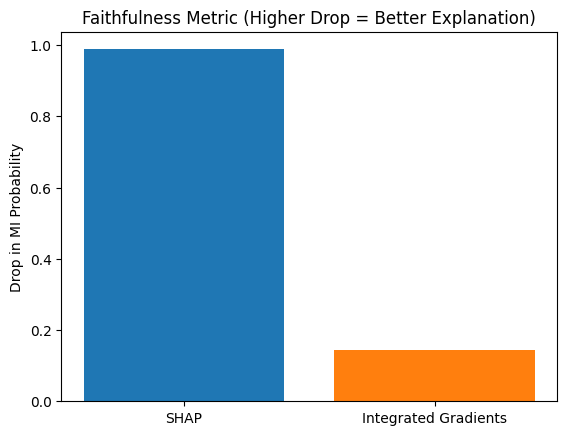

In [ ]:
if score_shap > score_ig:
    print("\nWinner: SHAP is more faithful for this sample.")
else:
    print("\nWinner: Integrated Gradients is more faithful for this sample.")

# Visualization
methods = ['SHAP', 'Integrated Gradients']
scores = [score_shap, score_ig]

plt.bar(methods, scores, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Drop in MI Probability')
plt.title('Faithfulness Metric (Higher Drop = Better Explanation)')
plt.show()

In [ ]:
instance_to_explain_index = 0
x_to_explain = X_scaled_test[instance_to_explain_index:instance_to_explain_index+1]

In [ ]:
# DeepLIFT

# Reshape background data to (100, 51, 1)
background_data_dl = background_data_2d.reshape(background_data_2d.shape[0], 51, 1)

# Reshape the instance to explain to (1, 51, 1)
x_to_explain_dl = x_to_explain.reshape(1, 51, 1)

In [ ]:
# initialize DeepLIFT
explainer_dl = shap.DeepExplainer(final_model, background_data_dl)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(100, 51, 1))']
  warnings.warn(msg)


In [ ]:
# compute DeepLIFT value for the whole test data
X_test_dl = X_scaled_test.reshape(X_scaled_test.shape[0], 51, 1)
#print(f"Calculating DeepLIFT values for {X_test_dl.shape[0]} samples...")
shap_values_dl = explainer_dl.shap_values(X_test_dl)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(200, 51, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_4
Received: inputs=['Tensor(shape=(112, 51, 1))']
  warnings.warn(msg)


In [ ]:
target_class_index = 0

In [ ]:
#attributions_dl = shap_values_dl[target_class_index].reshape(51)
attributions_dl = shap_values_dl[target_class_index][:, :, 0].flatten()

In [ ]:
num_samples = 40
scores_dl = []

print(f"Calculating faithfulness for {num_samples} samples (DeepLIFT - Class 1)...")

# Handle output structure
if isinstance(shap_values_dl, list):
    # List: [Class0, Class1]
    attributions_dl_all = shap_values_dl[1] # Class 1
elif len(shap_values_dl.shape) == 4 and shap_values_dl.shape[-1] == 2:
    # Stacked: (Samples, Features, Channels, Classes)
    attributions_dl_all = shap_values_dl[..., 1] # Class 1
else:
    attributions_dl_all = shap_values_dl

for i in range(num_samples):
    # Get the instance (keeping 2D shape (1, 51))
    instance = X_scaled_test_reshaped[i:i+1]

    # Get attributions for this sample and FLATTEN to (51,)
    # attributions_dl_all[i] should be (51, 1) or (51,)
    attributions = attributions_dl_all[i].flatten()

    # Calculate score
    score = calculate_faithfulness(final_model, instance, attributions, top_k=5)
    scores_dl.append(score)

# Calculate average
score_dl = np.mean(scores_dl)
print(f"Average Faithfulness Score (DeepLIFT) over {num_samples} samples: {score_dl}")

Calculating faithfulness for 40 samples (DeepLIFT - Class 1)...
Average Faithfulness Score (DeepLIFT) over 40 samples: 0.3783341944217682


/tmp/ipython-input-439236850.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, X_to_plot, feature_names=feature_names, plot_type='bar', max_display=10, show=False)


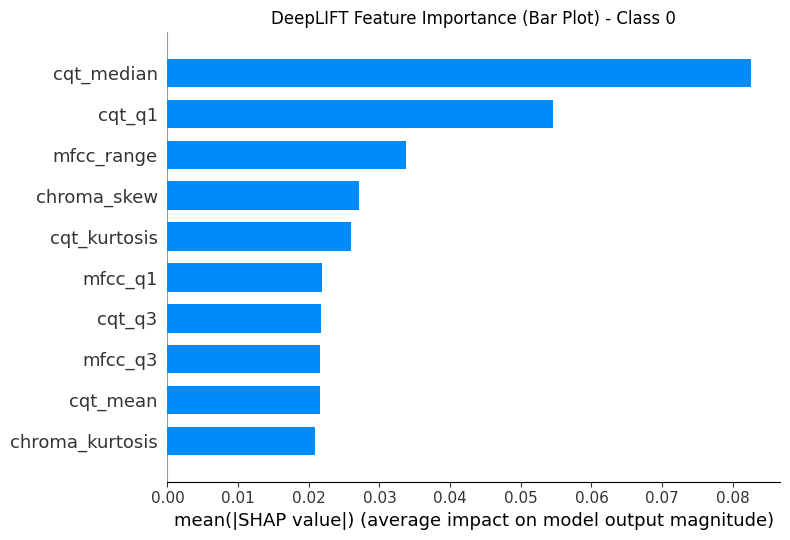

DeepLIFT summary plot (bar) generated.


In [ ]:
# 1. Handle Input Structure
if isinstance(shap_values_dl, list):
    # Standard SHAP list output: [Class0_Array, Class1_Array]
    shap_values_to_plot = shap_values_dl[0]
    #print("Detected list format.")
elif len(shap_values_dl.shape) == 4 and shap_values_dl.shape[-1] == 2:
    # Stacked array output: (Samples, Features, Channels, Classes)
    # Take Class 0
    shap_values_to_plot = shap_values_dl[..., 0]
    #print("Detected stacked array format (N, H, W, C).")
else:
    # Fallback / Single output
    shap_values_to_plot = shap_values_dl
    #print("Detected standard array format.")

# 2. Reshape to 2D (Samples, Features)
# Flatten (Samples, 51, 1) -> (Samples, 51)
shap_values_to_plot = shap_values_to_plot.reshape(shap_values_to_plot.shape[0], -1)
X_to_plot = X_scaled_test.reshape(X_scaled_test.shape[0], -1)

#print(f"Plotting shapes - SHAP: {shap_values_to_plot.shape}, X: {X_to_plot.shape}")

# 3. Generate Plot
shap.summary_plot(shap_values_to_plot, X_to_plot, feature_names=feature_names, plot_type='bar', max_display=10, show=False)
plt.title('DeepLIFT Feature Importance (Bar Plot) - Class 0')
plt.tight_layout()
plt.show()
print("DeepLIFT summary plot (bar) generated.")

In [ ]:
# Calculate mean absolute DeepLIFT values (global importance)
# Handle 4D shape (Samples, Features, Channels, Classes) or List

if isinstance(shap_values_dl, list):
    # List case: [Class0, Class1]
    # shap_values_dl[0] shape: (Samples, 51, 1)
    # Mean over samples -> (51, 1) -> Flatten to (51,)
    global_shap_values_dl = np.abs(shap_values_dl[0]).mean(axis=0).flatten()
elif len(shap_values_dl.shape) == 4 and shap_values_dl.shape[-1] == 2:
    # Stacked case: (Samples, 51, 1, 2)
    # Select Class 0 -> (Samples, 51, 1)
    # Mean over samples -> (51, 1) -> Flatten to (51,)
    global_shap_values_dl = np.abs(shap_values_dl[..., 0]).mean(axis=0).flatten()
else:
    # Standard case: (Samples, Features)
    global_shap_values_dl = np.abs(shap_values_dl).mean(axis=0).flatten()

# Create a DataFrame for easy sorting
feature_importance = pd.DataFrame(list(zip(feature_names, global_shap_values_dl)), columns=['feature', 'importance'])
feature_importance.sort_values(by='importance', ascending=False, inplace=True)

print("--- Top 3 Features from DeepLIFT Bar Plot (Mean |DeepLIFT value|) ---")
print(feature_importance.head(3))

--- Top 3 Features from DeepLIFT Bar Plot (Mean |DeepLIFT value|) ---
       feature  importance
20  cqt_median    0.082552
23      cqt_q1    0.054534
17  mfcc_range    0.033734


In [ ]:
feature_groups_dl = {
    'DWT': ['dwt_mean', 'dwt_max', 'dwt_min', 'dwt_median', 'dwt_q1', 'dwt_q3', 'dwt_iqr'],
    'MFCC': ['mfcc_mean', 'mfcc_std', 'mfcc_max', 'mfcc_median', 'mfcc_var', 'mfcc_skew', 'mfcc_kurtosis', 'mfcc_q1', 'mfcc_q3', 'mfcc_iqr', 'mfcc_range'],
    'CQT': ['cqt_mean', 'cqt_min', 'cqt_median', 'cqt_var', 'cqt_kurtosis', 'cqt_q1', 'cqt_q3', 'cqt_iqr', 'cqt_range'],
    'Chroma': ['chroma_mean', 'chroma_std', 'chroma_max', 'chroma_min', 'chroma_median', 'chroma_var', 'chroma_skew', 'chroma_kurtosis', 'chroma_q1', 'chroma_q3', 'chroma_iqr', 'chroma_range'],
    'RMS': ['rms_mean', 'rms_std', 'rms_max', 'rms_min', 'rms_median', 'rms_var', 'rms_skew', 'rms_kurtosis', 'rms_q1', 'rms_q3', 'rms_iqr', 'rms_range'],
    'Shannon Entropy': ['shannon_entropy']
}

grouped_attributions_dl = {group_name: 0.0 for group_name in feature_groups_dl.keys()}

# shap_values_to_plot (from the plot cell) has shape (Samples, Features)
# Calculate Mean Absolute Attribution per feature (Global Importance)
global_ig_importance = np.abs(shap_values_to_plot).mean(axis=0)

for i, feature_name in enumerate(feature_names):
    for group_name, group_features in feature_groups_dl.items():
        if feature_name in group_features:
            grouped_attributions_dl[group_name] += global_ig_importance[i]
            break # Move to the next feature once it's assigned to a group

print("\n--- Aggregated DeepLIFT Attribution Scores by Feature Group (Class 0: Myocardial) ---")
for group_name, total_attribution in sorted(grouped_attributions_dl.items(), key=lambda item: item[1], reverse=True):
    print(f"{group_name}: {total_attribution:.5f}")


--- Aggregated DeepLIFT Attribution Scores by Feature Group (Class 0: Myocardial) ---
CQT: 0.25116
Chroma: 0.17583
MFCC: 0.17411
DWT: 0.05347
RMS: 0.05218
Shannon Entropy: 0.00195


In [ ]:
def model_predict_wrapper(x):
    # Reshape input for the CNN
    x_reshaped = x.reshape(x.shape[0], 51, 1)

    # Get predictions
    preds = final_model.predict(x_reshaped, verbose=0)

    # Return probabilities for the target class (Class 0 based on your logs)
    # If you want Class 1, change to preds[:, 1]
    return preds[:, 0]

In [ ]:
explainer_generic = shap.Explainer(model_predict_wrapper, background_data_2d)

In [ ]:
# Reshape the whole test set to 2D (Samples, Features) to match the explainer's expectation
X_test_2d = X_scaled_test.reshape(X_scaled_test.shape[0], -1)

print(f"Calculating SHAP values (Generic) for {X_test_2d.shape[0]} samples...")
explanation_obj = explainer_generic(X_test_2d)

Calculating SHAP values (Generic) for 112 samples...


PermutationExplainer explainer: 113it [07:30,  4.02s/it]


In [ ]:
num_samples = 40
scores_shap_gen = []

print(f"Calculating faithfulness for {num_samples} samples (Generic Explainer - Class 1)...")

# The generic explainer was configured for Class 0 in the previous wrapper.
# For binary classification, Class 1 attributions are the negative of Class 0.
attributions_generic_all = -1 * explanation_obj.values

for i in range(num_samples):
    instance = X_scaled_test_reshaped[i:i+1]
    attributions = attributions_generic_all[i]
    score = calculate_faithfulness(final_model, instance, attributions, top_k=5)
    scores_shap_gen.append(score)

score_shap_gen = np.mean(scores_shap_gen)
print(f"Average Faithfulness Score (Generic Explainer) over {num_samples} samples: {score_shap_gen}")

Calculating faithfulness for 40 samples (Generic Explainer - Class 1)...
Average Faithfulness Score (Generic Explainer) over 40 samples: 0.3303169310092926


/tmp/ipython-input-3320043451.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, X_to_plot, feature_names=feature_names, plot_type='bar', max_display=10, show=False)


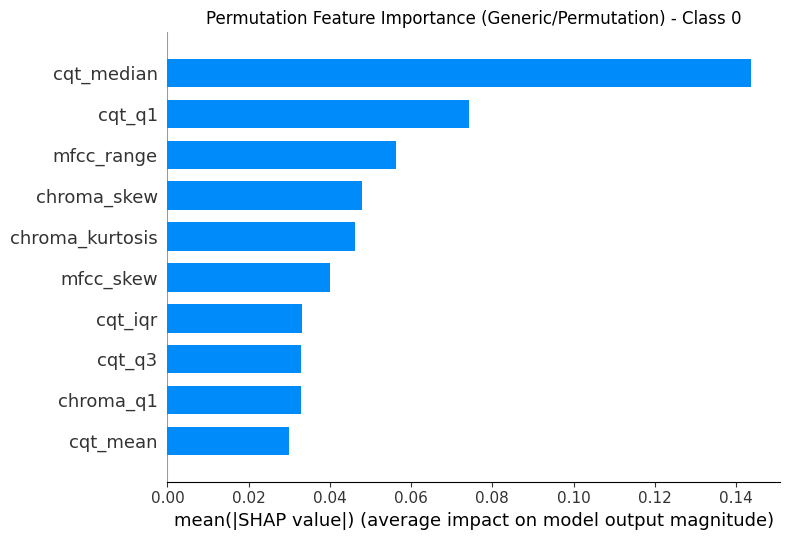

SHAP (Generic) summary plot (bar) generated.


In [ ]:
# Extract SHAP values from the generic explanation object (Class 0)
shap_values_to_plot = explanation_obj.values

# Reshape input to 2D for plotting
X_to_plot = X_scaled_test.reshape(X_scaled_test.shape[0], -1)

# Generate Plot
shap.summary_plot(shap_values_to_plot, X_to_plot, feature_names=feature_names, plot_type='bar', max_display=10, show=False)
plt.title('Permutation Feature Importance (Generic/Permutation) - Class 0')
plt.tight_layout()
plt.show()
print("SHAP (Generic) summary plot (bar) generated.")

In [ ]:
print("\n--- Top 3 Features from SHAP (Generic Explainer) ---")
# Calculate mean absolute SHAP values (global importance) from the Generic Explainer (Class 0)
global_shap_values_gen = np.abs(explanation_obj.values).mean(axis=0)

# Create DataFrame
feature_importance_gen = pd.DataFrame(list(zip(feature_names, global_shap_values_gen)), columns=['feature', 'importance'])
feature_importance_gen.sort_values(by='importance', ascending=False, inplace=True)

print(feature_importance_gen.head(3))


--- Top 3 Features from SHAP (Generic Explainer) ---
       feature  importance
20  cqt_median    0.143673
23      cqt_q1    0.074356
17  mfcc_range    0.056248


In [ ]:
grouped_attributions_generic = {group_name: 0.0 for group_name in feature_groups.keys()}

# global_shap_values_gen is already calculated as mean(|SHAP|) in the previous cell

for i, feature_name in enumerate(feature_names):
    for group_name, group_features in feature_groups.items():
        if feature_name in group_features:
            grouped_attributions_generic[group_name] += global_shap_values_gen[i]
            break # Move to the next feature once it's assigned to a group

print("\n--- Aggregated SHAP (Generic Explainer) Attribution Scores by Feature Group (Class 0: Myocardial) ---")
for group_name, total_attribution in sorted(grouped_attributions_generic.items(), key=lambda item: item[1], reverse=True):
    print(f"{group_name}: {total_attribution:.5f}")


--- Aggregated SHAP (Generic Explainer) Attribution Scores by Feature Group (Class 0: Myocardial) ---
CQT: 0.37027
Chroma: 0.28419
MFCC: 0.28225
RMS: 0.09935
DWT: 0.08399
Shannon Entropy: 0.00431



--- Faithfulness Comparison ---
Permutation Importance: 0.3303169310092926
SHAP: 0.2316545993089676
Integrated Gradients: 0.0032426267862319946
DeepLIFT: 0.3783341944217682

Winner: DeepLIFT is the most faithful method on average.


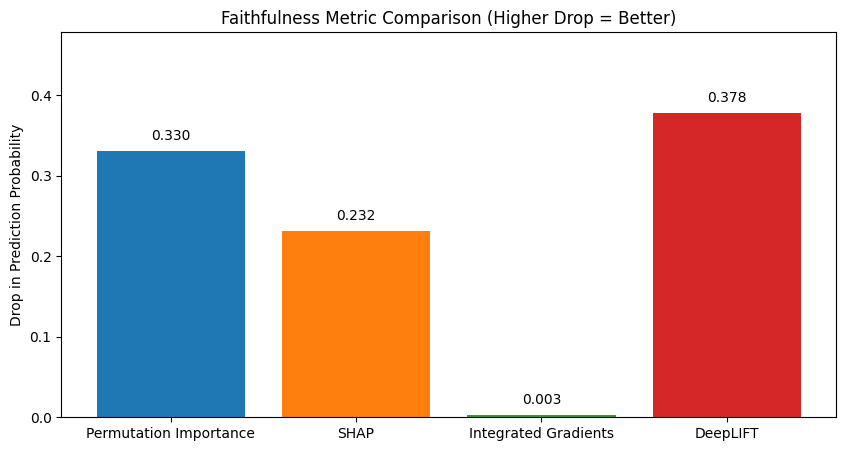

In [ ]:
print("\n--- Faithfulness Comparison ---")

# We create a dictionary to store all available scores for plotting
scores_dict = {'Permutation Importance': score_shap_gen}

# Check for scores from previous cells and add them if they exist
if 'score_shap' in locals():
    scores_dict['SHAP'] = score_shap
if 'score_ig' in locals():
    scores_dict['Integrated Gradients'] = score_ig
if 'score_dl' in locals():
    scores_dict['DeepLIFT'] = score_dl

# Print all scores
for method, score in scores_dict.items():
    print(f"{method}: {score}")

# Determine Winner
winner = max(scores_dict, key=scores_dict.get)
print(f"\nWinner: {winner} is the most faithful method on average.")

# Plotting
methods = list(scores_dict.keys())
scores = list(scores_dict.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, scores, color=colors[:len(methods)])
plt.ylabel('Drop in Prediction Probability')
plt.title('Faithfulness Metric Comparison (Higher Drop = Better)')
plt.ylim(0, max(scores) + 0.1) # Add headroom

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom')

plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
def get_integrated_gradients(model, input_sample, baseline=None, m_steps=50):
    """
    Calculates Integrated Gradients for a single sample.
    """
    # 1. Prepare Input and Baseline
    input_tensor = tf.cast(input_sample.reshape(1, 51, 1), tf.float32)

    if baseline is None:
        baseline = tf.zeros_like(input_tensor)
    else:
        baseline = tf.cast(baseline.reshape(1, 51, 1), tf.float32)

    # 2. Generate Path (Interpolated Inputs)
    # Shape: (m_steps + 1, 51, 1)
    alphas = tf.linspace(0.0, 1.0, m_steps+1)[:, tf.newaxis, tf.newaxis]
    interpolated_inputs = baseline + alphas * (input_tensor - baseline)

    # 3. Compute Gradients for each interpolated step
    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        # Get predictions for all steps at once
        preds = model(interpolated_inputs)
        # We assume Class 0 is the target based on previous logs.
        # Change to preds[:, 1] if you need Class 1
        score = preds[:, 0]

    # Get gradients w.r.t interpolated inputs
    grads = tape.gradient(score, interpolated_inputs)

    # 4. Integral Approximation (Trapezoidal Rule is better than simple average)
    # Average gradients (excluding first and last point usually improves stability,
    # but simple average is standard for basic IG)
    avg_grads = tf.reduce_mean(grads, axis=0)

    # 5. Compute Attribution: (Input - Baseline) * AvgGradient
    ig_attributions = (input_tensor - baseline) * avg_grads

    return ig_attributions.numpy().reshape(51)

In [ ]:
def get_noise_tunnel_ig(model, input_sample, m_steps=50, n_samples=5, noise_level=0.1):
    """
    Enhances IG by adding Gaussian noise (SmoothGrad) and averaging results.
    n_samples: Number of noisy samples to average.
    noise_level: Standard deviation of noise (relative to input range).
    """
    input_shape = input_sample.shape # (51,)

    # Storage for attributions
    ig_accumulated = np.zeros(51)

    # Calculate range for noise scaling (max - min of input)
    # If input is standardized, sigma=1 is essentially 1 standard deviation
    sigma = noise_level * (np.max(input_sample) - np.min(input_sample))
    if sigma == 0: sigma = 0.01 # Prevent zero noise if input is constant

    for _ in range(n_samples):
        # Add noise
        noise = np.random.normal(0, sigma, input_shape)
        noisy_input = input_sample + noise

        # Run Standard IG on noisy input
        # Note: We still use the original baseline (usually zeros)
        ig_val = get_integrated_gradients(model, noisy_input, m_steps=m_steps)
        ig_accumulated += ig_val

    # Average the results
    return ig_accumulated / n_samples

In [ ]:
num_samples = X_scaled_test.shape[0] # Use whole test data (112 samples)
scores_ig_standard = []
scores_ig_enhanced = []

print(f"Calculating IG faithfulness for {num_samples} samples (Class 1). This may take a few minutes...")

for i in range(num_samples):
    # Get instance (1, 51)
    instance = X_scaled_test_reshaped[i:i+1]

    # A. Standard IG (Class 0 -> Convert to Class 1 by multiplying by -1)
    # Increasing steps to 200 for better accuracy
    attr_std_c0 = get_integrated_gradients(final_model, instance, m_steps=200)
    attr_std_c1 = -1 * attr_std_c0
    s_std = calculate_faithfulness(final_model, instance, attr_std_c1, top_k=5)
    scores_ig_standard.append(s_std)

    # B. Noise Tunnel IG (Class 0 -> Convert to Class 1)
    # Using 10 samples and 50 steps
    attr_enh_c0 = get_noise_tunnel_ig(final_model, instance, m_steps=50, n_samples=10, noise_level=0.15)
    attr_enh_c1 = -1 * attr_enh_c0
    s_enh = calculate_faithfulness(final_model, instance, attr_enh_c1, top_k=5)
    scores_ig_enhanced.append(s_enh)

    if (i+1) % 20 == 0:
        print(f"Processed {i+1}/{num_samples} samples...")

score_ig_standard_avg = np.mean(scores_ig_standard)
score_ig_enhanced_avg = np.mean(scores_ig_enhanced)

# Update the main score_ig variable with the best result for comparison
score_ig = max(score_ig_standard_avg, score_ig_enhanced_avg)

print(f"\nAverage Faithfulness (Standard IG, 200 steps): {score_ig_standard_avg:.5f}")
print(f"Average Faithfulness (Noise Tunnel IG): {score_ig_enhanced_avg:.5f}")

Calculating IG faithfulness for 112 samples (Class 1). This may take a few minutes...
Processed 20/112 samples...
Processed 40/112 samples...
Processed 60/112 samples...
Processed 80/112 samples...
Processed 100/112 samples...

Average Faithfulness (Standard IG, 200 steps): 0.08451
Average Faithfulness (Noise Tunnel IG): 0.04096


In [ ]:
num_samples = 40
scores_ig_standard = []
scores_ig_enhanced = []

print(f"Calculating IG faithfulness for {num_samples} samples (Class 1). This may take a few minutes...")

for i in range(num_samples):
    # Get instance (1, 51)
    instance = X_scaled_test_reshaped[i:i+1]

    # A. Standard IG (Class 0 -> Convert to Class 1 by multiplying by -1)
    # Increasing steps to 200 for better accuracy
    attr_std_c0 = get_integrated_gradients(final_model, instance, m_steps=200)
    attr_std_c1 = -1 * attr_std_c0
    s_std = calculate_faithfulness(final_model, instance, attr_std_c1, top_k=5)
    scores_ig_standard.append(s_std)

    # B. Noise Tunnel IG (Class 0 -> Convert to Class 1)
    # Using 10 samples and 50 steps
    attr_enh_c0 = get_noise_tunnel_ig(final_model, instance, m_steps=50, n_samples=10, noise_level=0.15)
    attr_enh_c1 = -1 * attr_enh_c0
    s_enh = calculate_faithfulness(final_model, instance, attr_enh_c1, top_k=5)
    scores_ig_enhanced.append(s_enh)

    if (i+1) % 10 == 0:
        print(f"Processed {i+1}/{num_samples} samples...")

score_ig_standard_avg = np.mean(scores_ig_standard)
score_ig_enhanced_avg = np.mean(scores_ig_enhanced)

# Update the main score_ig variable with the best result for comparison
score_ig = max(score_ig_standard_avg, score_ig_enhanced_avg)

print(f"\nAverage Faithfulness (Standard IG, 200 steps): {score_ig_standard_avg:.5f}")
print(f"Average Faithfulness (Noise Tunnel IG): {score_ig_enhanced_avg:.5f}")

Calculating IG faithfulness for 40 samples (Class 1). This may take a few minutes...
Processed 10/40 samples...
Processed 20/40 samples...
Processed 30/40 samples...
Processed 40/40 samples...

Average Faithfulness (Standard IG, 200 steps): 0.23330
Average Faithfulness (Noise Tunnel IG): 0.31591


In [ ]:
def optimize_ig_search(model, x, baseline_score, step_options, sample_options):
    """
    Loops through step and sample combinations to find the highest faithfulness score.
    Returns the best attributions, best score, and the parameters used.
    """
    # 1. Initialization
    highest_score = -1.0
    best_attributions = None
    best_params = {"steps": 0, "samples": 0}

    # Header for the print log
    print(f"Target Baseline (Standard IG): {baseline_score:.4f}")
    print(f"{'Steps':<8} | {'Samples':<8} | {'Score':<10} | {'Status'}")
    print("-" * 50)

    # 2. Search Loop
    for s_val in step_options:
        for n_val in sample_options:

            # Run Noise Tunnel IG
            attr_trial = get_noise_tunnel_ig(
                model,
                x,
                m_steps=s_val,
                n_samples=n_val,
                noise_level=0.15 # Keep this constant or make it an argument
            )

            # Calculate Score
            current_score = calculate_faithfulness(model, x, attr_trial, top_k=5)

            # Determine Status for Printing
            status_icon = ""
            if current_score > highest_score:
                status_icon = "⭐ New Best"
                # Update our champion variables
                highest_score = current_score
                best_attributions = attr_trial
                best_params = {"steps": s_val, "samples": n_val}
            elif current_score > baseline_score:
                status_icon = "✅ Beats Baseline"
            else:
                status_icon = "❌ Lower"

            # Print row
            print(f"{s_val:<8} | {n_val:<8} | {current_score:<10.4f} | {status_icon}")

    # 3. Final Summary
    print("-" * 50)
    print(f"Optimization Complete.")
    print(f"Winner: Steps={best_params['steps']}, Samples={best_params['samples']} with Score: {highest_score:.4f}")

    return best_attributions, highest_score, best_params

In [ ]:
step_range = [50, 100, 150]
sample_range = [10, 20, 30]
num_samples = 40

print(f"Optimizing IG parameters over {num_samples} samples (Class 1)...")
print(f"{'Steps':<8} | {'Samples':<8} | {'Avg Score':<10} | {'Status'}")
print("-" * 50)

highest_score = -float('inf')
best_params = {}

for s_val in step_range:
    for n_val in sample_range:
        batch_scores = []
        for i in range(num_samples):
             # Get instance
            instance = X_scaled_test_reshaped[i:i+1]
            # Run Noise Tunnel IG (Class 0)
            attr_c0 = get_noise_tunnel_ig(final_model, instance, m_steps=s_val, n_samples=n_val, noise_level=0.15)
            # Invert for Class 1 (Normal)
            attr_c1 = -1 * attr_c0
            # Score
            s = calculate_faithfulness(final_model, instance, attr_c1, top_k=5)
            batch_scores.append(s)

        avg_score = np.mean(batch_scores)

        status = ""
        if avg_score > highest_score:
            highest_score = avg_score
            best_params = {'steps': s_val, 'samples': n_val}
            status = "⭐ New Best"

        print(f"{s_val:<8} | {n_val:<8} | {avg_score:<10.5f} | {status}")

print("-" * 50)
print(f"Optimization Complete.")
print(f"Winner: Steps={best_params['steps']}, Samples={best_params['samples']} with Avg Score: {highest_score:.5f}")

# Update global best score for comparison plot
best_score = highest_score

Optimizing IG parameters over 40 samples (Class 1)...
Steps    | Samples  | Avg Score  | Status
--------------------------------------------------
50       | 10       | 0.25653    | ⭐ New Best
50       | 20       | 0.28585    | ⭐ New Best
50       | 30       | 0.38231    | ⭐ New Best
100      | 10       | 0.22448    | 
100      | 20       | 0.34690    | 
100      | 30       | 0.36582    | 
150      | 10       | 0.22194    | 
150      | 20       | 0.26887    | 
150      | 30       | 0.32580    | 
--------------------------------------------------
Optimization Complete.
Winner: Steps=50, Samples=30 with Avg Score: 0.38231


In [ ]:
print("\n--- Integrated Gradients Enhancement Results ---")
print(f"Standard IG (50 steps):      {score_ig_standard_avg}")
print(f"Enhanced IG (Noise Tunnel):  {best_score}")


--- Integrated Gradients Enhancement Results ---
Standard IG (50 steps):      0.23330041766166687
Enhanced IG (Noise Tunnel):  0.3823113441467285



--- Faithfulness Comparison ---
Permutation Importance: 0.3303169310092926
SHAP: 0.2316545993089676
Integrated Gradients: 0.23330041766166687
DeepLIFT: 0.3783341944217682

Winner: DeepLIFT is the most faithful for this sample.


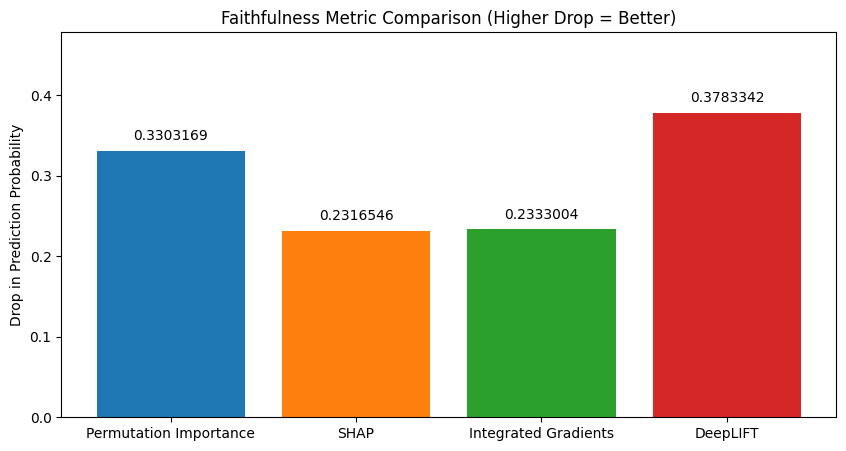

In [ ]:
print("\n--- Faithfulness Comparison ---")

# We create a dictionary to store all available scores for plotting
scores_dict = {'Permutation Importance': score_shap_gen}

# Check for scores from previous cells and add them if they exist
if 'score_shap' in locals():
    scores_dict['SHAP'] = score_shap
if 'score_ig' in locals():
    scores_dict['Integrated Gradients'] = score_ig_standard_avg
if 'score_dl' in locals():
    scores_dict['DeepLIFT'] = score_dl

# Print all scores
for method, score in scores_dict.items():
    print(f"{method}: {score}")

# Determine Winner
winner = max(scores_dict, key=scores_dict.get)
print(f"\nWinner: {winner} is the most faithful for this sample.")

# Plotting
methods = list(scores_dict.keys())
scores = list(scores_dict.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, scores, color=colors[:len(methods)])
plt.ylabel('Drop in Prediction Probability')
plt.title('Faithfulness Metric Comparison (Higher Drop = Better)')
plt.ylim(0, max(scores) + 0.1) # Add headroom

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.7f}", ha='center', va='bottom')

plt.show()


--- Faithfulness Comparison ---
Permutation Importance: 0.3303169310092926
SHAP: 0.2316545993089676
Integrated Gradients: 0.3823113441467285
DeepLIFT: 0.3783341944217682

Winner: Integrated Gradients is the most faithful for this sample.


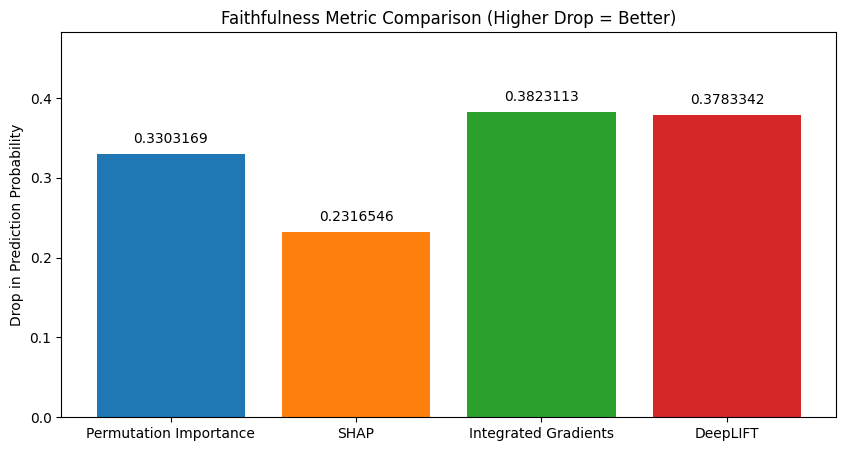

In [ ]:
print("\n--- Faithfulness Comparison ---")

# We create a dictionary to store all available scores for plotting
scores_dict = {'Permutation Importance': score_shap_gen}

# Check for scores from previous cells and add them if they exist
if 'score_shap' in locals():
    scores_dict['SHAP'] = score_shap
if 'score_ig' in locals():
    scores_dict['Integrated Gradients'] = best_score
if 'score_dl' in locals():
    scores_dict['DeepLIFT'] = score_dl

# Print all scores
for method, score in scores_dict.items():
    print(f"{method}: {score}")

# Determine Winner
winner = max(scores_dict, key=scores_dict.get)
print(f"\nWinner: {winner} is the most faithful for this sample.")

# Plotting
methods = list(scores_dict.keys())
scores = list(scores_dict.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, scores, color=colors[:len(methods)])
plt.ylabel('Drop in Prediction Probability')
plt.title('Faithfulness Metric Comparison (Higher Drop = Better)')
plt.ylim(0, max(scores) + 0.1) # Add headroom

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.7f}", ha='center', va='bottom')

plt.show()